In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

[ Info: Precompiling ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79]


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [11]:
d = 10
nsamples = 1000
T = 50

50

In [12]:
M = randn(d,d) * 0.5
J = M * M'

10×10 Matrix{Float64}:
  2.35927     0.456623   -1.14161    …  -0.499902   0.0530666   0.844766
  0.456623    2.05633     0.0780014      0.592163  -0.301556    0.571961
 -1.14161     0.0780014   3.05034        1.14862   -0.438018   -1.83082
 -0.0248096  -0.601589   -1.54895       -1.64481   -0.355682    0.648085
  0.123223   -0.42937    -1.12433        0.53472    0.416988    1.01247
 -0.271257    0.364658    1.18895    …   0.539821   0.346123   -1.09863
 -0.158171    0.686186   -0.301254      -0.76971   -1.55911     0.574168
 -0.499902    0.592163    1.14862        2.91283    0.705533    0.247464
  0.0530666  -0.301556   -0.438018       0.705533   2.71226    -0.0149487
  0.844766    0.571961   -1.83082        0.247464  -0.0149487   2.24104

In [13]:
eigen(inv(J))

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
10-element Vector{Float64}:
  0.13122518268200725
  0.20188903538543182
  0.26055933219993715
  0.3895601326039787
  0.6336623170404848
  1.0927211966118902
  1.7031515448156016
  2.6812145196301382
 18.435121356758902
 23.944896010233727
vectors:
10×10 Matrix{Float64}:
 -0.221995   -0.210562     0.178752   …   0.00832099  -0.0592087   0.11067
  0.0344126   0.00281495   0.581763       0.156309     0.0363244   0.400817
  0.561885    0.296079     0.0436198     -0.46644      0.295635    0.381478
 -0.434449    0.198255    -0.278553       0.300548     0.198452    0.227006
 -0.151335   -0.313702     0.0569048      0.152773     0.274258    0.585852
  0.292593    0.0517418    0.0170517  …   0.363758     0.602403   -0.389045
 -0.227597    0.415078     0.384471      -0.24096     -0.306711   -0.107801
  0.367491   -0.394591     0.378686       0.334603    -0.276737   -0.140109
  0.110852   -0.556094    -0.350069      -0.367156    -0

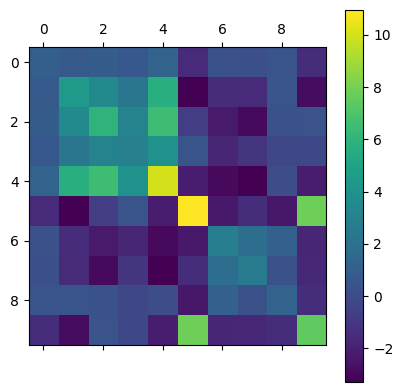

PyObject <matplotlib.colorbar.Colorbar object at 0x72ce53643f40>

In [14]:
matshow(inv(J))
colorbar()

In [23]:
θ0 = zeros(d)
θ1 = 1.5 * randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

5.9775675451026595

In [24]:
γ = 0.1

0.1

In [25]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

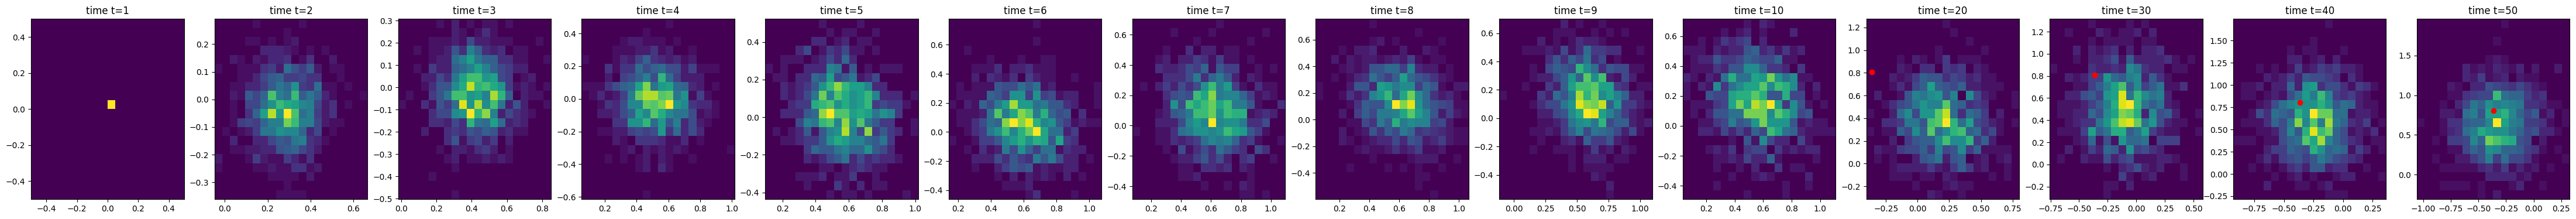

In [26]:
tpoints = [1,2,3,4,5,6,7,8,9,10,20,30,40,50]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

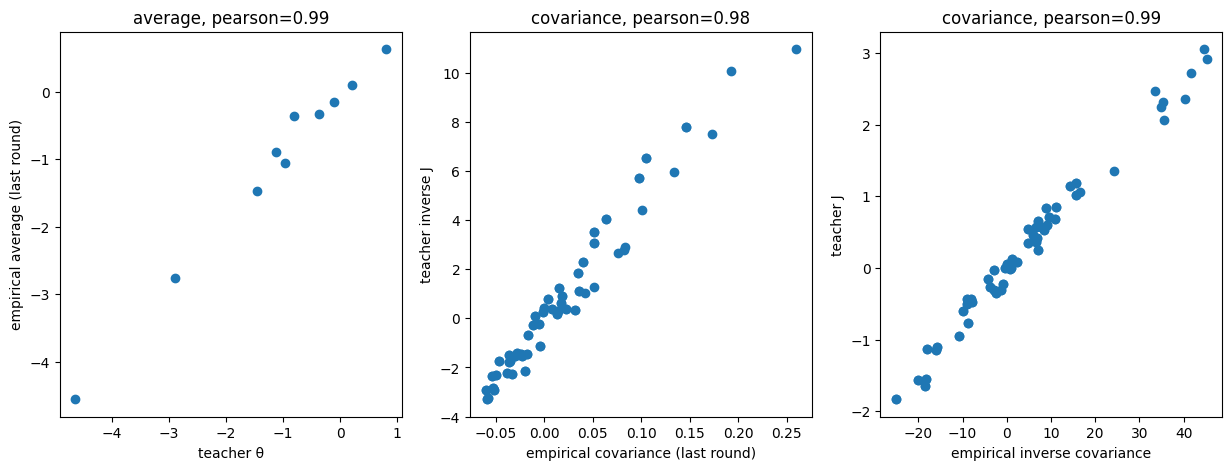

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [27]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [30]:
t_sample=[1, 2, 3, 4, 5, 6]

6-element Vector{Int64}:
 1
 2
 3
 4
 5
 6

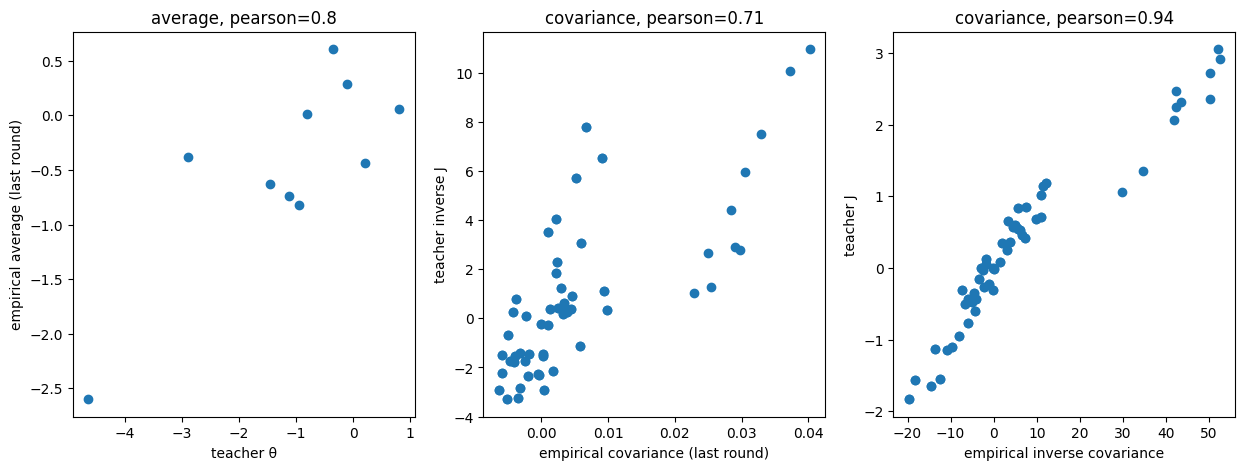

PyObject Text(0.5, 1.0, 'covariance, pearson=0.94')

In [35]:
fig, ax = subplots(1,3,5)
μ_last = mean(x[:,:,t_sample[end]], dims=2)
Σ_last = ((x[:,:,t_sample[end]] .- μ_last)*(x[:,:,t_sample[end]] .- μ_last)')./nsamples

ax[1].scatter(θ, μ_last)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_last))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_last), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_last), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_last)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_last)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [32]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
deltas = [1,1,1,1,1]
data = collect_data(x[:,:,t_sample], counts, deltas);

In [33]:
l_values_gamma, x_opt_gamma, status_gamma = learn_gamma_nlopt(data, initialize=length(t_sample), λ=0.0, prior=0.01, ftol_rel=1e-9)

(minf = -22.060588733151675, minx = [0.8761967040490769, -0.06525009767151409, 0.4306458372635301, -0.891332692153441, 0.06606417984897733, 0.9478850657239938, 0.24960642846305386, 0.5257969075517354, -0.07243521015569464, -0.9988897727928221  …  -0.5418851578377432, -1.6986237079158604, 1.8438376386181927, -1.517186942622797, -0.7978505207296857, 2.2182587796103936, -2.0391037317871756, -2.4195048957172665, -0.6770745028480709, 0.01523471229844327], status = :FTOL_REACHED, nevals = 32069, x_start = [50.12372209174311, 6.634074112775075, 41.8235777887299, -10.776786157112959, 1.4511614959083583, 51.99859708828703, -2.585524214266101, -4.347710352948731, -12.379609002345013, 42.39745612239153  …  0.05828733865159073, -0.6241281592093343, -0.379364169020242, -0.4379747856694548, 0.013777880226689201, 0.28557216269844654, -2.600061649473641, -0.8184243121099456, -0.7373054704684818, 1.0])

In [34]:
@save "test3_A_save.jld2" J θ x l_values_gamma x_opt_gamma status_gamma

In [36]:
x_opt_gamma[end]

0.01523471229844327

In [37]:
J_inferred = de.compute_J(x_opt_gamma, data.d);
θ_inferred = de.compute_theta(x_opt_gamma, data.d);

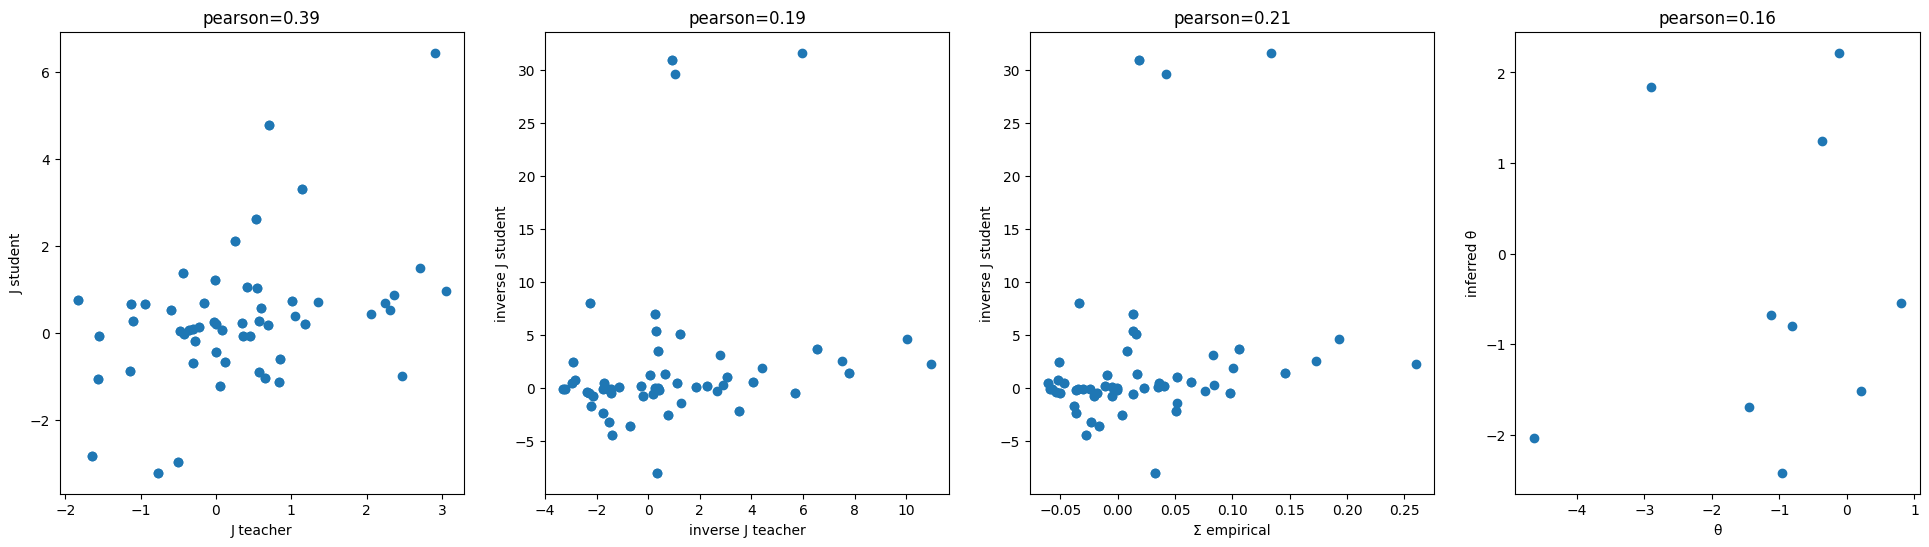

PyObject Text(0.5, 1.0, 'pearson=0.16')

In [38]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, θ_inferred)
rho_theta = cor(vec(θ), θ_inferred)
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [40]:
γ = collect(0.001:0.002:1.0)#vcat([0.001, 0.005], collect(0.1:0.1:1.5))

500-element Vector{Float64}:
 0.001
 0.003
 0.005
 0.007
 0.009
 0.011
 0.013
 0.015
 0.017
 0.019
 0.021
 0.023
 0.025
 ⋮
 0.977
 0.979
 0.981
 0.983
 0.985
 0.987
 0.989
 0.991
 0.993
 0.995
 0.997
 0.999

In [42]:
lγ = map(x->de.log_likelihood(x_opt_gamma[1:end-1], data, x, 0.0, 0.01), γ)

500-element Vector{Float64}:
 208.8311766609713
  31.58609809704329
  -0.36146994753621003
 -12.306372360432313
 -17.81021086792154
 -20.487061673647936
 -21.69598317899384
 -22.057147821350153
 -21.891608420408396
 -21.381121418633043
 -20.63571839802568
 -19.725585850905826
 -18.69741704952667
   ⋮
 103.4823512394547
 103.5161488233421
 103.5498626681798
 103.58349339254117
 103.61704160964692
 103.65050793085757
 103.68389296010923
 103.71719729535897
 103.75042153409514
 103.78356626626584
 103.81663207576462
 103.84961954446321

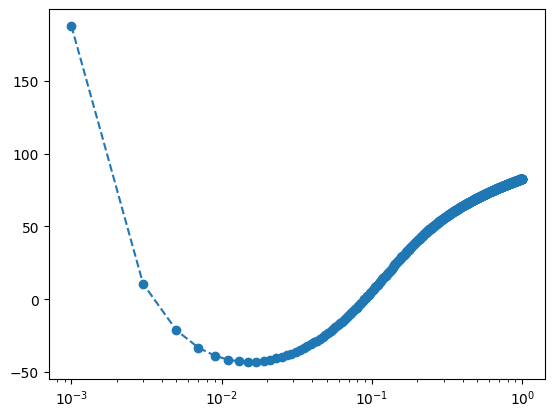

In [43]:
plot(γ, lγ .+ (minimum(lγ) + 1.0), linestyle="dashed", marker="o")
xscale(:log)